# **XGBClassifier**

---

Versão 2.0.0

## **Importação das bibliotecas**

In [42]:
import pandas as pd
import numpy as np
import binascii
import seaborn as sns
from micromlgen import port
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## **Leitura do dataset e Separação de features e target**

In [43]:
# 1. Leitura dos dados

# Caminho do CSV
#arquivo = "../data/dataset/FDS1118EE05.csv" # Escala Macro 05A
#arquivo = "../data/dataset/FDS1024EE05.csv" # Escala Micro 05A
arquivo = "../data/dataset/FDS0317EE10.csv" # Escala Macro 10A

# Lê o CSV
dados = pd.read_csv(arquivo)

# Tratamento de valores ausentes
dados2 = dados.fillna(-100)


In [44]:
# Separação de features e target
y = dados['ambiente']

In [45]:
# ===== IDENTIFICAR COLUNAS RSSI =====
colunas_rssi = dados.columns[2:]

# ===== FUNÇÃO DE AJUSTE POR AMBIENTE =====
def ajustar_por_ambiente(df):

    mask_nan = df[colunas_rssi].isna()

    # mínimo dentro do ambiente
    min_local = df[colunas_rssi].min().min()

    # preenchimento base
    df[colunas_rssi] = df[colunas_rssi].fillna(min_local)

    # quantidade de APs detectados por linha
    df["qtd_aps_detectados"] = (~mask_nan).sum(axis=1)

    # média de APs detectados no ambiente
    media_aps = df["qtd_aps_detectados"].mean()

    # penalização relativa ao ambiente
    penalizacao = (media_aps - df["qtd_aps_detectados"]).clip(lower=0) * 1.5

    df[colunas_rssi] = df[colunas_rssi].sub(penalizacao, axis=0)

    # limite físico
    df[colunas_rssi] = df[colunas_rssi].clip(lower=-100)

    return df

# ===== APLICAR POR AMBIENTE =====
dados = dados.groupby("ambiente", group_keys=False).apply(ajustar_por_ambiente)

In [ ]:
dados

In [ ]:
X = dados.iloc[:, 1:-1]
X2 = dados.iloc[:,2:]
X

## **Codificação das classes (LabelEncoder)**

In [48]:
# 2. Codificação das classes

# Conversão das classes para números
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Tabela do mapeamento realizado
df_labels = pd.DataFrame({'Ambiente': le.classes_, 'LabelEncoder': range(len(le.classes_))})
print("\nMapeamento das Classes:")
print(df_labels)


Mapeamento das Classes:
                                Ambiente  LabelEncoder
0             Auditório de Eng. Elétrica             0
1           Coordenação de Eng. Elétrica             1
2    Coordenação de pós em Eng. Elétrica             2
3                 Coordenação de química             3
4                    Lab. Informática 09             4
5       Lab. de Instrumentação biomédica             5
6          Lab. de aferição e calibração             6
7                       Lab. de biologia             7
8                 Lab. de fibras ópticas             8
9                         Lab. de física             9
10                    Lab. de matemática            10
11  Lab. de medições em telecomunicações            11
12                   Lab. de microscopia            12
13            Lab. de redes convergentes            13
14              Lab. de telecomunicações            14
15                       Lab. química 01            15
16                       Lab. química 02

## **Modelo utilizado**

In [49]:
# 3. Modelo Utilizado

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=24,                     # Número de Classes
    n_estimators=14,                  # Número de árvores de decisão por classe.
    max_depth=2,                      # Profundidade máxima de cada árvore.
    learning_rate=0.4,                  # Controla o tamanho do passo de aprendizado. 0.5
    subsample=0.8,                    # Significa que cada árvore usa apenas 80% das amostras.
    colsample_bytree=0.8,             # Cada árvore usa apenas 80% das features.
    eval_metric='merror' #eval_metric='mlogloss'            # Define a função de erro usada na classificação multiclasse
)

## **Detector de Hiperparâmetros Ideais**

In [ ]:
# Parâmetros
N_estimators = [8, 10, 12, 14, 15]
Learning_rate = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

resultados = []  # lista para salvar tudo

# Loop correto
for n_est in N_estimators:
    for lr in Learning_rate:

        medias = []

        for i in range(20):

            xgb_model = xgb.XGBClassifier(
                objective="multi:softprob",
                num_class=24,
                n_estimators=n_est,
                max_depth=2,
                learning_rate=lr,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric='merror',
            )

            kfold = StratifiedKFold(n_splits=5, shuffle=True)

            cv_scores = cross_val_score(
                xgb_model,
                X,
                y_encoded,
                cv=kfold,
                scoring='accuracy'
            )

            media_fold = cv_scores.mean()
            medias.append(media_fold)

            print(f"[n_estimators={n_est}, lr={lr}] Rodada {i+1} - Acurácia: {media_fold:.4f}")

        # Estatísticas finais
        media_final = np.mean(medias)
        desvio_final = np.std(medias)

        print("\n======================================")
        print(f"n_estimators={n_est} | learning_rate={lr}")
        print(f"Acurácia média: {media_final:.4f}")
        print(f"Desvio padrão: {desvio_final:.4f}")
        print("======================================\n")

        # Salvar resultado
        resultados.append({
            "n_estimators": n_est,
            "learning_rate": lr,
            "media_acuracia": media_final,
            "desvio_padrao": desvio_final
        })

# Criar DataFrame final
df_resultados = pd.DataFrame(resultados)

# Ordenar pelos melhores
df_resultados = df_resultados.sort_values(by="media_acuracia", ascending=False)

# Salvar em CSV
df_resultados.to_csv("resultados_xgboost.csv", index=False)

print("\nTabela final:")
print(df_resultados)
    

## **Validação Cruzada - KFold**

In [50]:
# 4. Validação Cruzada

medias = []

for i in range(10):

    kfold = StratifiedKFold(n_splits=5, shuffle=True)

    cv_scores = cross_val_score(
        xgb_model,
        X,
        y_encoded,
        cv=kfold,
        scoring='accuracy'
    )

    media_fold = cv_scores.mean()
    medias.append(media_fold)

    print(f"Rodada {i+1} - Acurácia média: {media_fold:.4f}")

# Resultado final consolidado
media_final = np.mean(medias)
desvio_final = np.std(medias)

print("\n======================================")
print("=========== Modelo XGBoost ===========")
print("======================================")
print("Acurácia média (20 execuções): {:.4f}".format(media_final))
print("Desvio padrão entre execuções: {:.4f}".format(desvio_final))

Rodada 1 - Acurácia média: 0.8375
Rodada 2 - Acurácia média: 0.8333
Rodada 3 - Acurácia média: 0.8167
Rodada 4 - Acurácia média: 0.8417
Rodada 5 - Acurácia média: 0.8208
Rodada 6 - Acurácia média: 0.8125
Rodada 7 - Acurácia média: 0.8333
Rodada 8 - Acurácia média: 0.8458
Rodada 9 - Acurácia média: 0.8583
Rodada 10 - Acurácia média: 0.8417

=========== Modelo XGBoost ===========
Acurácia média (20 execuções): 0.8342
Desvio padrão entre execuções: 0.0134


## **Separação dos dados**

In [73]:
# 5. Divisão treino/teste

#X_train, X_test, y_train, y_test = train_test_split(X, y_encoded,test_size=0.2, stratify=y_encoded)

# ===== ALINHAR COLUNAS ENTRE X E X2 =====

# Garantir mesmas colunas
X2 = X2.reindex(columns=X.columns, fill_value=-100)

# ===== SPLIT POR ÍNDICE =====
idx_train, idx_test = train_test_split(
    range(len(y_encoded)),
    test_size=0.2,
    stratify=y_encoded
)

# ===== APLICAR NOS DATASETS =====
X_train = X.iloc[idx_train]
y_train = y_encoded[idx_train]

X_test = X2.iloc[idx_test]
y_test = y_encoded[idx_test]

## **Treinamento do modelo**

In [74]:
# 6. Treinamento Final

xgb_model.fit(X_train, y_train)

preds = xgb_model.predict(X_test)

acc = accuracy_score(y_test, preds)

print(f"\nAcurácia no conjunto de teste: {acc:.4f} ({acc*100:.2f}%)")
print("\nAcurácia no conjunto de teste:", accuracy_score(y_test, preds))


Acurácia no conjunto de teste: 0.8333 (83.33%)

Acurácia no conjunto de teste: 0.8333333333333334


## **Detector de melhor Modelo**

In [76]:
max_tentativas = 100
tentativa = 0
acc = 0
minimo = 0.9

while acc < minimo and tentativa < max_tentativas:
    tentativa += 1
    # 5. Divisão treino/teste

    # ===== SPLIT POR ÍNDICE =====
    idx_train, idx_test = train_test_split(
        range(len(y_encoded)),
        test_size=0.2,
        stratify=y_encoded
    )

    # ===== APLICAR NOS DATASETS =====
    X_train = X.iloc[idx_train]
    y_train = y_encoded[idx_train]

    X_test = X2.iloc[idx_test]
    y_test = y_encoded[idx_test]

    # 6. Treinamento Final

    xgb_model.fit(X_train, y_train)

    preds = xgb_model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print(f"\nAcurácia no conjunto de teste: {acc:.4f} ({acc*100:.2f}%)")
    print("\nAcurácia no conjunto de teste:", accuracy_score(y_test, preds))
if acc >= 0.93:
    print(f"\nAtingiu {acc*100:.2f}% de acurácia!")
else:
    print(f"\nNão atingiu {minimo:.2f}% dentro do limite.")


Acurácia no conjunto de teste: 0.8958 (89.58%)

Acurácia no conjunto de teste: 0.8958333333333334

Acurácia no conjunto de teste: 0.8333 (83.33%)

Acurácia no conjunto de teste: 0.8333333333333334

Acurácia no conjunto de teste: 0.7708 (77.08%)

Acurácia no conjunto de teste: 0.7708333333333334

Acurácia no conjunto de teste: 0.8333 (83.33%)

Acurácia no conjunto de teste: 0.8333333333333334

Acurácia no conjunto de teste: 0.8958 (89.58%)

Acurácia no conjunto de teste: 0.8958333333333334

Acurácia no conjunto de teste: 0.9375 (93.75%)

Acurácia no conjunto de teste: 0.9375

Atingiu 93.75% de acurácia!


## **Matriz de Confusão**

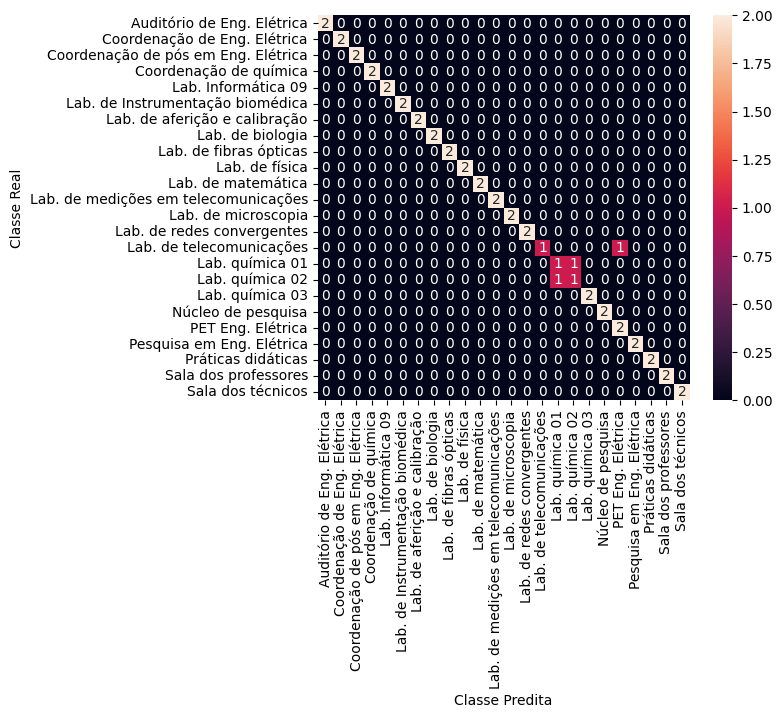

In [77]:
# Matriz de Confusão em um único DataFrame

cm = confusion_matrix(y_test, preds)

cm_df = pd.DataFrame(
    cm,
    index=le.classes_,
    columns=le.classes_
)

# Transformando em um único DataFrame estruturado
cm_df = cm_df.reset_index()
cm_df = cm_df.rename(columns={'index': 'Classe_Real'})

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.savefig("../images/matrizConfusaoXGBoostVirtualMacro10.png", dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
print("\nMatriz de Confusão (DataFrame único):")
cm_df

In [ ]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, preds))

In [ ]:
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, preds))

## **Conversão para C**

In [ ]:
# Mapeamento de classes (índice → nome da classe)

class_map = {i: classe for i, classe in enumerate(le.classes_)}

In [ ]:
with open('../firmware/models/XGBClassifierMacro10.h', 'w') as file:
    file.write(port(xgb_model, classmap=class_map))

## **Conversão de MAC para CRC32**

In [ ]:
# Extrai apenas as colunas que são MACs
macs = list(dados.columns[2:])

def mac_to_crc32(mac):
    return binascii.crc32(mac.encode()) & 0xFFFFFFFF


print("uint32_t macHashList[] = {")

for i, mac in enumerate(macs):
    crc = mac_to_crc32(mac)

    # Imprime o valor
    print(f"0x{crc:08X}, ", end="")

    # Quebra linha a cada 5 elementos
    if (i + 1) % 5 == 0:
        print()

# Garante quebra final se não for múltiplo de 5
if len(macs) % 5 != 0:
    print()

print("};")

In [ ]:
macs

In [ ]:
const char* idxToLabel(uint8_t classIdx) {
    switch (classIdx) {
        case 0:
        return "Auditório de Eng. Elétrica";
        case 1:
        return "Coordenação de Eng. Elétrica";
        case 2:
        return "Coordenação de pós em Eng. Elétrica";
        case 3:
        return "Coordenação de química";
        case 4:
        return "Lab. Informática 09";
        case 5:
        return "Lab. de Instrumentação biomédica";
        case 6:
        return "Lab. de aferição e calibração";
        case 7:
        return "Lab. de biologia";
        case 8:
        return "Lab. de fibras ópticas";
        case 9:
        return "Lab. de física";
        case 10:
        return "Lab. de matemática";
        case 11:
        return "Lab. de medições em telecomunições";
        case 12:
        return "Lab. de microscopia";
        case 13:
        return "Lab. de redes convergentes";
        case 14:
        return "Lab. de telecomunicações";
        case 15:
        return "Lab. química 01";
        case 16:
        return "Lab. química 02";
        case 17:
        return "Lab. química 03";
        case 18:
        return "Núcleo de pesquisa";
        case 19:
        return "PET Eng. Elétrica";
        case 20:
        return "Pesquisa em Eng. Elétrica";
        case 21:
        return "Práticas didáticas";
        case 22:
        return "Sala dos professores";
        case 23:
        return "Sala dos técnicos";
        default:
        return "Houston we have a problem";
    }
}

In [ ]:
const char* idxToLabel(uint8_t classIdx) {
    switch (classIdx) {
        case 0:
        return "Auditório de Eng. Elétrica";
        case 1:
        return "Coordenação de Eng. Elétrica";
        case 2:
        return "Coordenação de pós em Eng. Elétrica";
        case 3:
        return "Lab. Informática 09";
        case 4:
        return "Lab. de Instrumentação biomédica";
        case 5:
        return "Lab. de aferição e calibração";
        case 6:
        return "Lab. de fibras ópticas";
        case 7:
        return "Lab. de medições em telecomunições";
        case 8:
        return "Lab. de redes convergentes";
        case 9:
        return "Lab. de telecomunicações";
        case 10:
        return "PET Eng. Elétrica";
        case 11:
        return "Pesquisa em Eng. Elétrica";
        case 12:
        return "Práticas didáticas";
        case 13:
        return "Sala dos professores";
        case 14:
        return "Sala dos técnicos";
        default:
        return "Houston we have a problem";
    }
}